<a href="https://colab.research.google.com/github/alizasultanaesd-png/skill-morph-work/blob/main/4_report_water_quality_measurementb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
# Install required packages (run this first in Google Colab)
!pip install numpy pandas matplotlib seaborn

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
!pip install adjustText

**overall water quality**


# **Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()


# Load data
df = pd.read_excel("overall_water_wuality.xlsx")
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')
from adjustText import adjust_text  # Now this will work!

Saving overall_water_wuality.xlsx to overall_water_wuality.xlsx


In [4]:
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

In [5]:
from adjustText import adjust_text  # Now this will work!


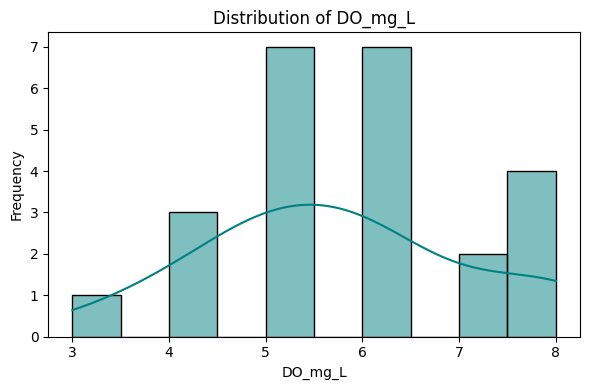

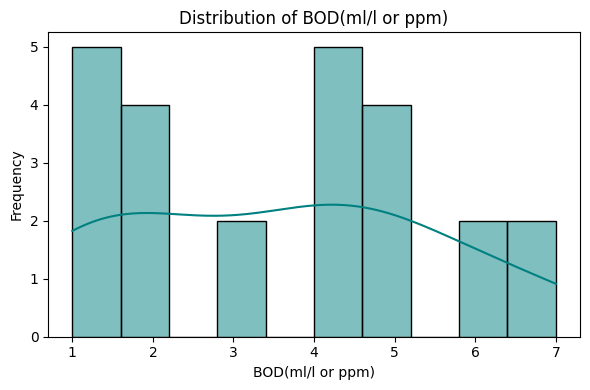

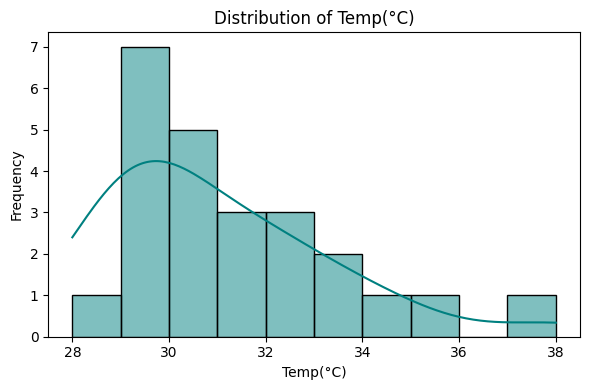

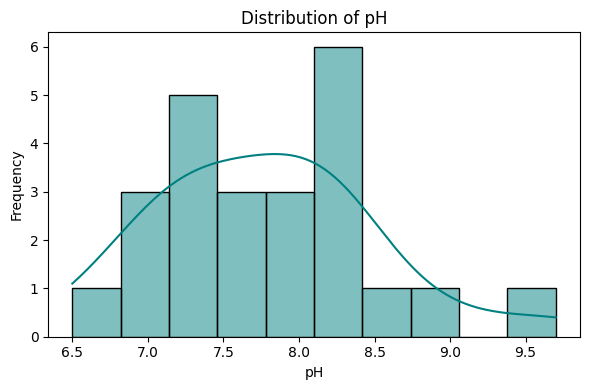

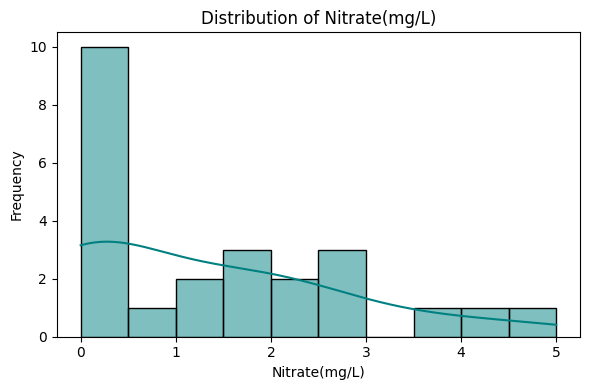

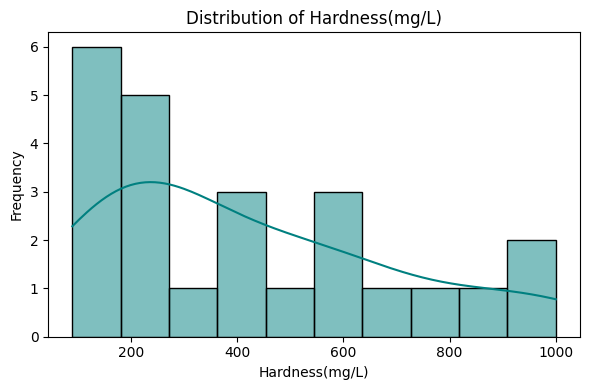

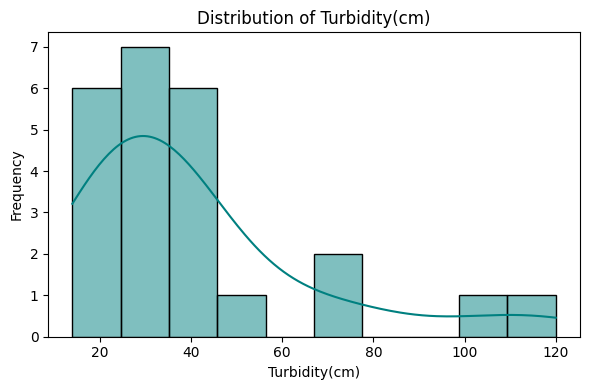

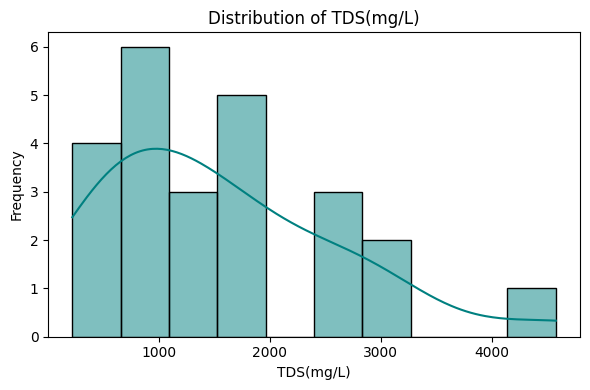

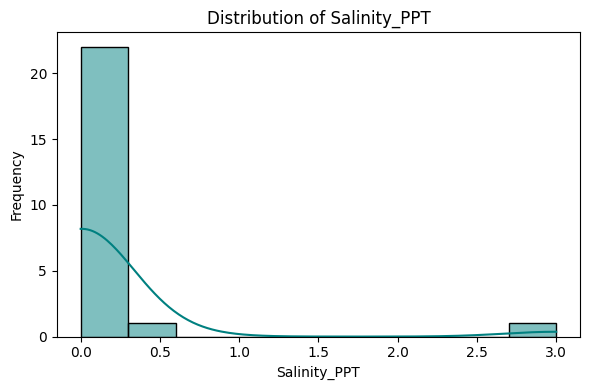


🔍 Normality Test for DO_mg_L:
Shapiro-Wilk p-value: 0.0769
D’Agostino-Pearson p-value: 0.8403
Water Quality Data Exhibits Normal Distribution—Suitable for Parametric Analysis

🔍 Normality Test for BOD(ml/l or ppm):
Shapiro-Wilk p-value: 0.0593
D’Agostino-Pearson p-value: 0.2387
Water Quality Data Exhibits Normal Distribution—Suitable for Parametric Analysis

🔍 Normality Test for Temp(°C):
Shapiro-Wilk p-value: 0.0074
D’Agostino-Pearson p-value: 0.0079
“Water Quality Data Does Not Follow Normal Distribution—Consider Non-Parametric Methods

🔍 Normality Test for pH:
Shapiro-Wilk p-value: 0.5775
D’Agostino-Pearson p-value: 0.2248
Water Quality Data Exhibits Normal Distribution—Suitable for Parametric Analysis

🔍 Normality Test for Nitrate(mg/L):
Shapiro-Wilk p-value: 0.0016
D’Agostino-Pearson p-value: 0.0983
“Water Quality Data Does Not Follow Normal Distribution—Consider Non-Parametric Methods

🔍 Normality Test for Hardness(mg/L):
Shapiro-Wilk p-value: 0.0094
D’Agostino-Pearson p-value: 

In [6]:
# 📦 Step 1: Install & Import Required Libraries
!pip install pandas matplotlib seaborn scipy openpyxl --quiet

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest

# 📂 Step 2: Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Step 3: Select Numeric Columns (excluding Latitude & Longitude)
exclude_cols = ['Latitude', 'Longitude']
numeric_cols = df.select_dtypes(include='number').drop(columns=exclude_cols, errors='ignore').columns
df_clean = df[numeric_cols].dropna()

# 📊 Step 4: Visual Check (Histogram + KDE)
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_clean[col], kde=True, bins=10, color='teal')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# 🧪 Step 5: Statistical Tests for Normality
for col in numeric_cols:
    print(f"\n🔍 Normality Test for {col}:")

    # Shapiro-Wilk Test
    stat_shapiro, p_shapiro = shapiro(df_clean[col])
    print(f"Shapiro-Wilk p-value: {p_shapiro:.4f}")

    # D’Agostino and Pearson’s Test
    stat_dagostino, p_dagostino = normaltest(df_clean[col])
    print(f"D’Agostino-Pearson p-value: {p_dagostino:.4f}")


    #  Summary
    if p_shapiro < 0.05 or p_dagostino < 0.05:
        print("“Water Quality Data Does Not Follow Normal Distribution—Consider Non-Parametric Methods")
    else:
        print("Water Quality Data Exhibits Normal Distribution—Suitable for Parametric Analysis")


In [73]:
# 📦 Install & Import
!pip install pandas scipy openpyxl --quiet

import pandas as pd
from scipy.stats import ttest_ind

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Filter Two Groups
group1 = df[df['Sampling_Station'] == 'P19_St-1']['DO_mg_L'].dropna()
group2 = df[df['Sampling_Station'] == 'P20_St-1']['DO_mg_L'].dropna()

# 🧪 Perform t-Test
t_stat, p_val = ttest_ind(group1, group2)

# 📊 Output
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.3f}")

# 📌 Bengali Summary
if p_val < 0.05:
    print("significant difference in mean dissolved oxygen (DO) levels between the two sampling stations")
else:
    print(" no significant difference in mean dissolved oxygen (DO) levels between the two sampling stations")


t-statistic: nan
p-value: nan
 no significant difference in mean dissolved oxygen (DO) levels between the two sampling stations


In [79]:
# 📦 Install & Import
!pip install pandas scipy openpyxl --quiet

import pandas as pd
from scipy.stats import ttest_ind

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🔍 Define two stations
station1 = 'P19_St-1'
station2 = 'P20_St-1'

# 🧪 Loop through parameters
for col in ['DO_mg_L', 'BOD(ml/l or ppm)', 'pH']:
    group1 = df[df['Sampling_Station'] == station1][col].dropna()
    group2 = df[df['Sampling_Station'] == station2][col].dropna()

    if len(group1) > 0 and len(group2) > 0:
        t_stat, p_val = ttest_ind(group1, group2)
        print(f"\n🔍 Independent t-test for {col}:")
        print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")

        # 📌 Bengali Summary
        if p_val < 0.05:
            print(f"❌ {station1} এবং {station2} এর মধ্যে {col} মানে উল্লেখযোগ্য পার্থক্য আছে।")
        else:
            print(f"✅ {station1} এবং {station2} এর মধ্যে {col} মানে উল্লেখযোগ্য পার্থক্য নেই।")
    else:
        print(f"\n⚠️ {col} এর জন্য পর্যাপ্ত ডেটা নেই।")



🔍 Independent t-test for DO_mg_L:
t-statistic: nan, p-value: nan
✅ P19_St-1 এবং P20_St-1 এর মধ্যে DO_mg_L মানে উল্লেখযোগ্য পার্থক্য নেই।

🔍 Independent t-test for BOD(ml/l or ppm):
t-statistic: nan, p-value: nan
✅ P19_St-1 এবং P20_St-1 এর মধ্যে BOD(ml/l or ppm) মানে উল্লেখযোগ্য পার্থক্য নেই।

🔍 Independent t-test for pH:
t-statistic: nan, p-value: nan
✅ P19_St-1 এবং P20_St-1 এর মধ্যে pH মানে উল্লেখযোগ্য পার্থক্য নেই।


In [83]:
# 📦 Install & Import
!pip install pandas scipy openpyxl --quiet

import pandas as pd
from scipy.stats import ttest_ind

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Step 1: Create Group Labels
df['Station_Group'] = df['Sampling_Station'].str.extract(r'(P19|P20)')

# 🧪 Step 2: Loop through parameters
for col in ['DO_mg_L', 'BOD(ml/l or ppm)', 'pH']:
    group1 = df[df['Station_Group'] == 'P19'][col].dropna()
    group2 = df[df['Station_Group'] == 'P20'][col].dropna()

    if len(group1) > 1 and len(group2) > 1:
        t_stat, p_val = ttest_ind(group1, group2)
        print(f"\n🔍 Independent t-test for {col} (P19 vs P20):")
        print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")

        # 📌 Bengali Summary
        if p_val < 0.05:
            print(f"❌ P19 এবং P20 এর মধ্যে {col} মানে উল্লেখযোগ্য পার্থক্য আছে।")
        else:
            print(f"✅ P19 এবং P20 এর মধ্যে {col} মানে উল্লেখযোগ্য পার্থক্য নেই।")
    else:
        print(f"\n⚠️ {col} এর জন্য পর্যাপ্ত ডেটা নেই।")



🔍 Independent t-test for DO_mg_L (P19 vs P20):
t-statistic: 0.752, p-value: 0.464
✅ P19 এবং P20 এর মধ্যে DO_mg_L মানে উল্লেখযোগ্য পার্থক্য নেই।

🔍 Independent t-test for BOD(ml/l or ppm) (P19 vs P20):
t-statistic: -1.948, p-value: 0.072
✅ P19 এবং P20 এর মধ্যে BOD(ml/l or ppm) মানে উল্লেখযোগ্য পার্থক্য নেই।

🔍 Independent t-test for pH (P19 vs P20):
t-statistic: -4.248, p-value: 0.001
❌ P19 এবং P20 এর মধ্যে pH মানে উল্লেখযোগ্য পার্থক্য আছে।


In [84]:
# 📦 Install & Import
!pip install pandas scipy openpyxl --quiet

import pandas as pd
from scipy.stats import ttest_ind

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Step 1: Create Group Labels
df['Station_Group'] = df['Sampling_Station'].str.extract(r'(P19|P20|P21)')

# 🧪 Step 2: Define Combined Group
df['Combined_Group'] = df['Station_Group'].replace({'P19': 'P19_P20', 'P20': 'P19_P20'})

# 🧪 Step 3: Loop through parameters
for col in ['DO_mg_L', 'BOD(ml/l or ppm)', 'pH']:
    group1 = df[df['Combined_Group'] == 'P19_P20'][col].dropna()
    group2 = df[df['Combined_Group'] == 'P21'][col].dropna()

    if len(group1) > 1 and len(group2) > 1:
        t_stat, p_val = ttest_ind(group1, group2)
        print(f"\n🔍 Independent t-test for {col} (P19+P20 vs P21):")
        print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")

        # 📌 Bengali Summary
        if p_val < 0.05:
            print(f"❌ P19+P20 এবং P21 এর মধ্যে {col} মানে উল্লেখযোগ্য পার্থক্য আছে।")
        else:
            print(f"✅ P19+P20 এবং P21 এর মধ্যে {col} মানে উল্লেখযোগ্য পার্থক্য নেই।")
    else:
        print(f"\n⚠️ {col} এর জন্য পর্যাপ্ত ডেটা নেই।")



🔍 Independent t-test for DO_mg_L (P19+P20 vs P21):
t-statistic: -1.983, p-value: 0.060
✅ P19+P20 এবং P21 এর মধ্যে DO_mg_L মানে উল্লেখযোগ্য পার্থক্য নেই।

🔍 Independent t-test for BOD(ml/l or ppm) (P19+P20 vs P21):
t-statistic: 0.072, p-value: 0.943
✅ P19+P20 এবং P21 এর মধ্যে BOD(ml/l or ppm) মানে উল্লেখযোগ্য পার্থক্য নেই।

🔍 Independent t-test for pH (P19+P20 vs P21):
t-statistic: -1.292, p-value: 0.210
✅ P19+P20 এবং P21 এর মধ্যে pH মানে উল্লেখযোগ্য পার্থক্য নেই।


In [86]:
# Install and import required libraries
!pip install pandas scipy openpyxl --quiet

import pandas as pd
from scipy.stats import mannwhitneyu

# Load the dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# Extract station group (P19, P20, P21)
df['Station_Group'] = df['Sampling_Station'].str.extract(r'(P19|P20|P21)')

# Define parameters to test
parameters = ['Temp(°C)', 'Nitrate(mg/L)', 'Hardness(mg/L)', 'Turbidity(cm)', 'TDS(mg/L)', 'Salinity_PPT']

# Perform Mann-Whitney U test for each parameter
print("\n🔍 Mann-Whitney U Test (P19 vs P20):")
for col in parameters:
    group1 = df[df['Station_Group'] == 'P19'][col].dropna()
    group2 = df[df['Station_Group'] == 'P20'][col].dropna()

    if len(group1) > 1 and len(group2) > 1:
        stat, p_val = mannwhitneyu(group1, group2)
        print(f"\n{col}:")
        print(f"U-statistic: {stat:.3f}, p-value: {p_val:.3f}")
        if p_val < 0.05:
            print(f"❌ Significant difference in {col} between P19 and P20.")
        else:
            print(f"✅ No significant difference in {col} between P19 and P20.")
    else:
        print(f"\n⚠️ Insufficient data for {col}.")



🔍 Mann-Whitney U Test (P19 vs P20):

Temp(°C):
U-statistic: 14.000, p-value: 0.062
✅ No significant difference in Temp(°C) between P19 and P20.

Nitrate(mg/L):
U-statistic: 33.000, p-value: 0.958
✅ No significant difference in Nitrate(mg/L) between P19 and P20.

Hardness(mg/L):
U-statistic: 56.000, p-value: 0.013
❌ Significant difference in Hardness(mg/L) between P19 and P20.

Turbidity(cm):
U-statistic: 46.000, p-value: 0.156
✅ No significant difference in Turbidity(cm) between P19 and P20.

TDS(mg/L):
U-statistic: 59.000, p-value: 0.003
❌ Significant difference in TDS(mg/L) between P19 and P20.

Salinity_PPT:
U-statistic: 36.000, p-value: 0.382
✅ No significant difference in Salinity_PPT between P19 and P20.


In [87]:
from scipy.stats import kruskal

# Perform Kruskal-Wallis test for each parameter
print("\n\n🔍 Kruskal-Wallis Test (P19 vs P20 vs P21):")
for col in parameters:
    g1 = df[df['Station_Group'] == 'P19'][col].dropna()
    g2 = df[df['Station_Group'] == 'P20'][col].dropna()
    g3 = df[df['Station_Group'] == 'P21'][col].dropna()

    if len(g1) > 1 and len(g2) > 1 and len(g3) > 1:
        stat, p_val = kruskal(g1, g2, g3)
        print(f"\n{col}:")
        print(f"H-statistic: {stat:.3f}, p-value: {p_val:.3f}")
        if p_val < 0.05:
            print(f"❌ Significant difference in {col} among P19, P20, and P21.")
        else:
            print(f"✅ No significant difference in {col} among P19, P20, and P21.")
    else:
        print(f"\n⚠️ Insufficient data for {col}.")




🔍 Kruskal-Wallis Test (P19 vs P20 vs P21):

Temp(°C):
H-statistic: 4.497, p-value: 0.106
✅ No significant difference in Temp(°C) among P19, P20, and P21.

Nitrate(mg/L):
H-statistic: 8.955, p-value: 0.011
❌ Significant difference in Nitrate(mg/L) among P19, P20, and P21.

Hardness(mg/L):
H-statistic: 6.632, p-value: 0.036
❌ Significant difference in Hardness(mg/L) among P19, P20, and P21.

Turbidity(cm):
H-statistic: 2.990, p-value: 0.224
✅ No significant difference in Turbidity(cm) among P19, P20, and P21.

TDS(mg/L):
H-statistic: 7.835, p-value: 0.020
❌ Significant difference in TDS(mg/L) among P19, P20, and P21.

Salinity_PPT:
H-statistic: 1.049, p-value: 0.592
✅ No significant difference in Salinity_PPT among P19, P20, and P21.


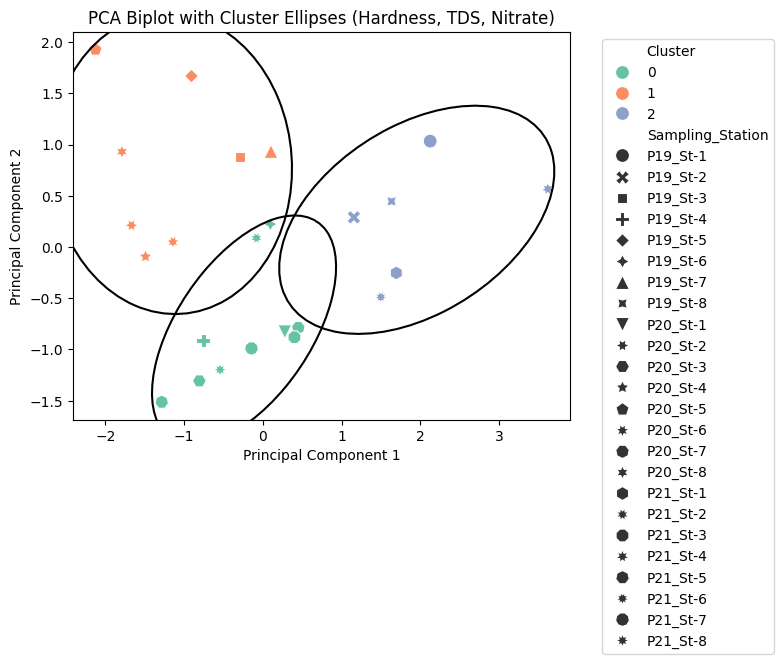

In [89]:
#  PCA + Clustering for Hardness, TDS, Nitrate📦 Install & Import
!pip install pandas matplotlib seaborn scikit-learn openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from matplotlib.patches import Ellipse

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Select Relevant Columns
features = ['Hardness(mg/L)', 'TDS(mg/L)', 'Nitrate(mg/L)']
df_clean = df[['Sampling_Station'] + features].dropna()

# 🔄 Standardize Features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[features])

# 📈 PCA Transformation
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# 🎯 Clustering (KMeans)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# 🧮 Add Results to DataFrame
df_clean['PCA1'] = pca_result[:, 0]
df_clean['PCA2'] = pca_result[:, 1]
df_clean['Cluster'] = clusters

# 📊 PCA Biplot with Ellipses
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='PCA1', y='PCA2', hue='Cluster', style='Sampling_Station', palette='Set2', s=100)

# ➰ Draw Ellipses Around Clusters
for cluster_id in df_clean['Cluster'].unique():
    cluster_data = df_clean[df_clean['Cluster'] == cluster_id][['PCA1', 'PCA2']]
    if len(cluster_data) > 2:
        cov = np.cov(cluster_data.T)
        lambda_, v = np.linalg.eig(cov)
        lambda_ = np.sqrt(lambda_)
        mean = cluster_data.mean().values
        angle = np.degrees(np.arctan2(*v[:, 0][::-1]))
        ellipse = Ellipse(xy=mean, width=lambda_[0]*4, height=lambda_[1]*4,
                          angle=angle, edgecolor='black', fc='none', lw=1.5)
        plt.gca().add_patch(ellipse)

plt.title('PCA Biplot with Cluster Ellipses (Hardness, TDS, Nitrate)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


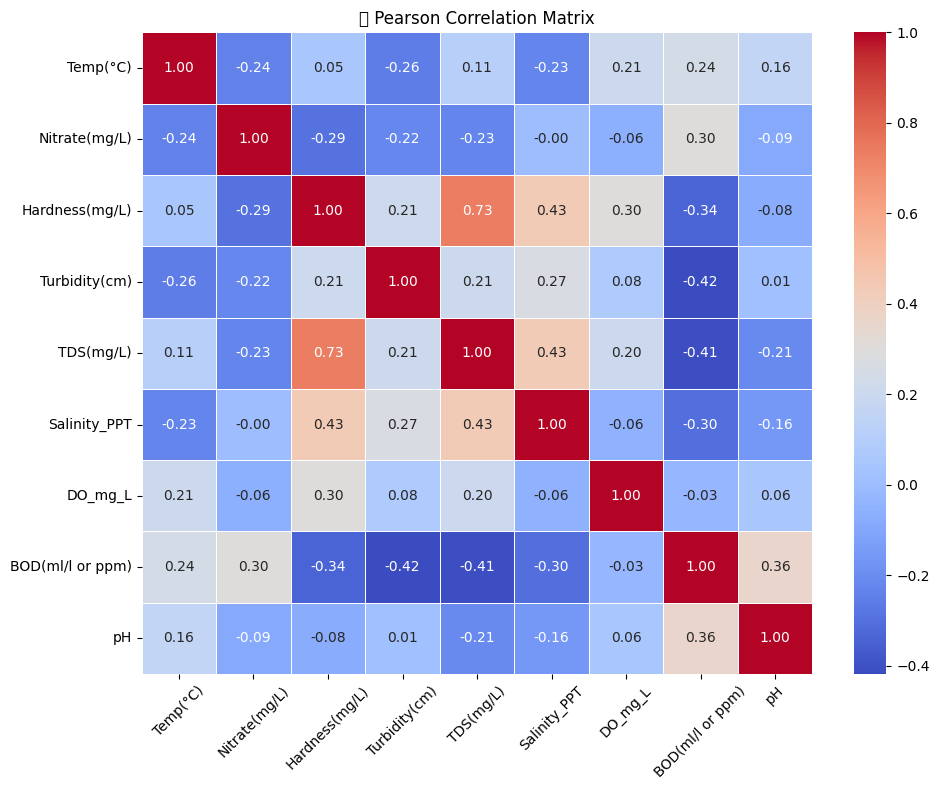

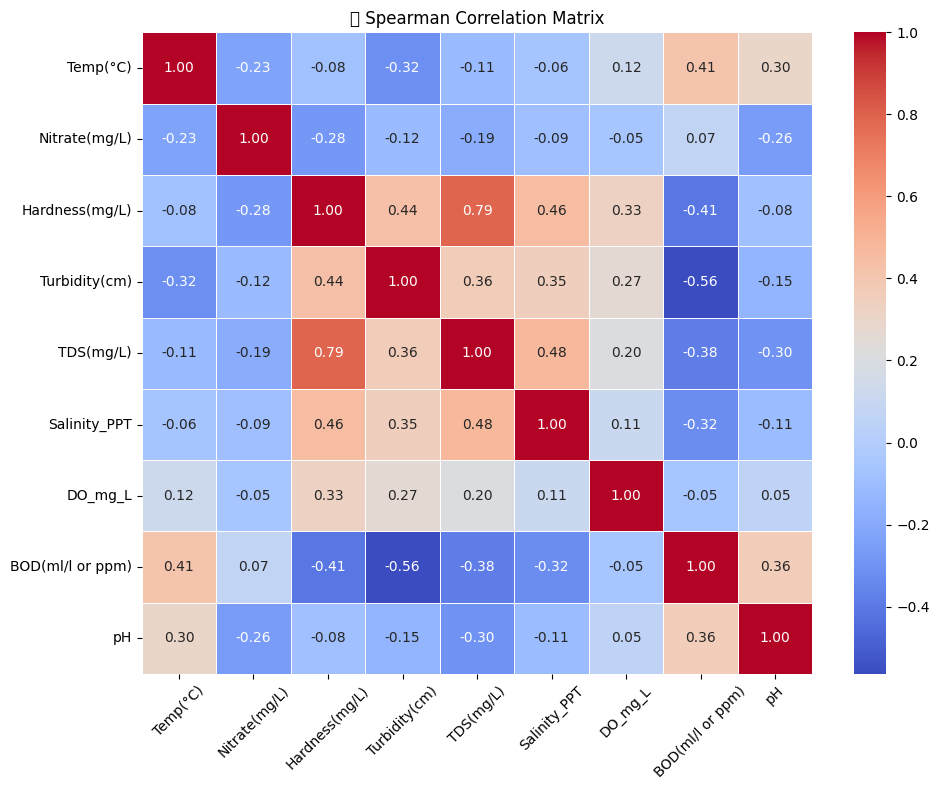

In [90]:
#Correlation Matrix + Heatmap (Pearson & Spearman) 📦 Install & Import
!pip install pandas seaborn matplotlib openpyxl --quiet

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Select Numeric Parameters
parameters = ['Temp(°C)', 'Nitrate(mg/L)', 'Hardness(mg/L)', 'Turbidity(cm)', 'TDS(mg/L)', 'Salinity_PPT',
              'DO_mg_L', 'BOD(ml/l or ppm)', 'pH']
df_numeric = df[parameters].dropna()

# 📊 Pearson Correlation Matrix
pearson_corr = df_numeric.corr(method='pearson')

# 📊 Spearman Correlation Matrix
spearman_corr = df_numeric.corr(method='spearman')

# 📈 Heatmap Function
def plot_heatmap(corr_matrix, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 🔍 Plot Both Heatmaps
plot_heatmap(pearson_corr, '📊 Pearson Correlation Matrix')
plot_heatmap(spearman_corr, '📊 Spearman Correlation Matrix')


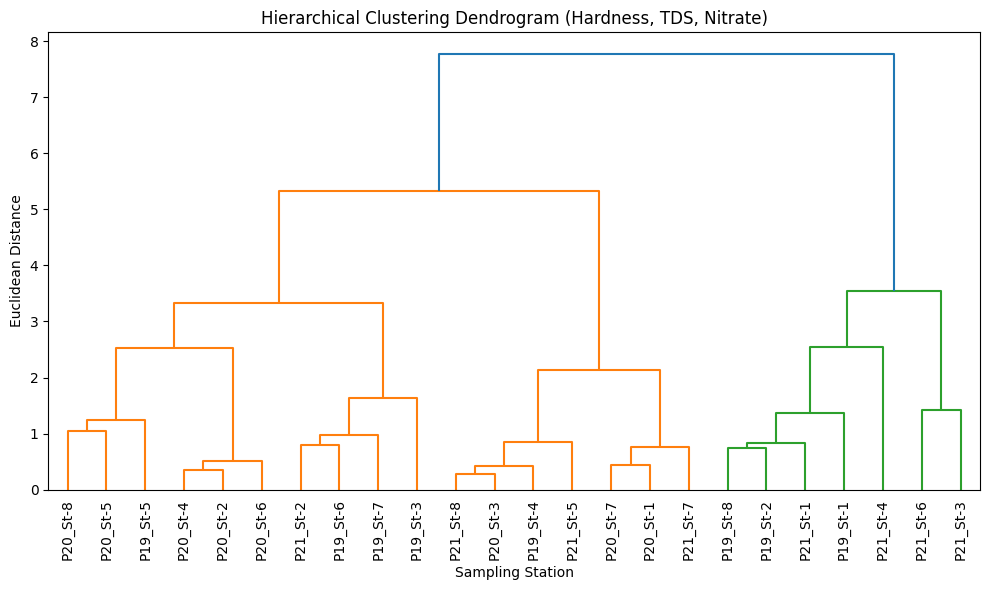

In [91]:
#Hierarchical Clustering with Dendrogram 📦 Install & Import
!pip install pandas matplotlib seaborn scipy openpyxl --quiet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Select Relevant Columns
features = ['Hardness(mg/L)', 'TDS(mg/L)', 'Nitrate(mg/L)']
df_clean = df[['Sampling_Station'] + features].dropna()

# 🔄 Standardize Features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[features])

# 🌳 Hierarchical Clustering
linked = linkage(scaled_data, method='ward')

# 📊 Dendrogram Plot
plt.figure(figsize=(10, 6))
dendrogram(linked,
           labels=df_clean['Sampling_Station'].values,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Hardness, TDS, Nitrate)')
plt.xlabel('Sampling Station')
plt.ylabel('Euclidean Distance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


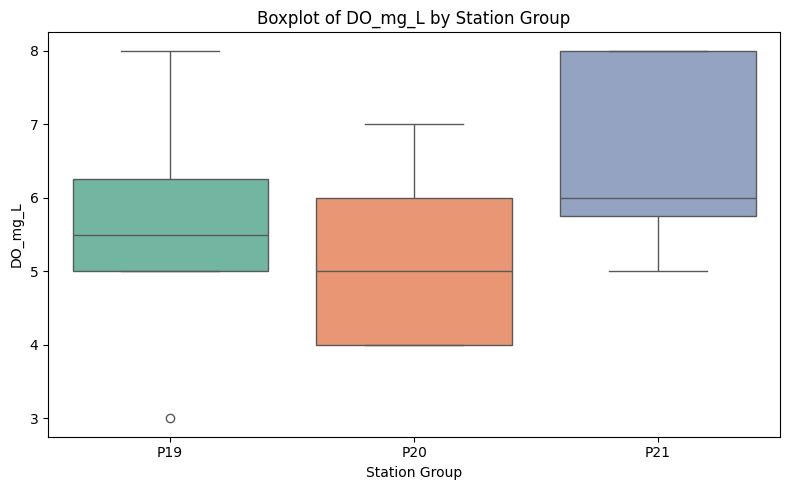

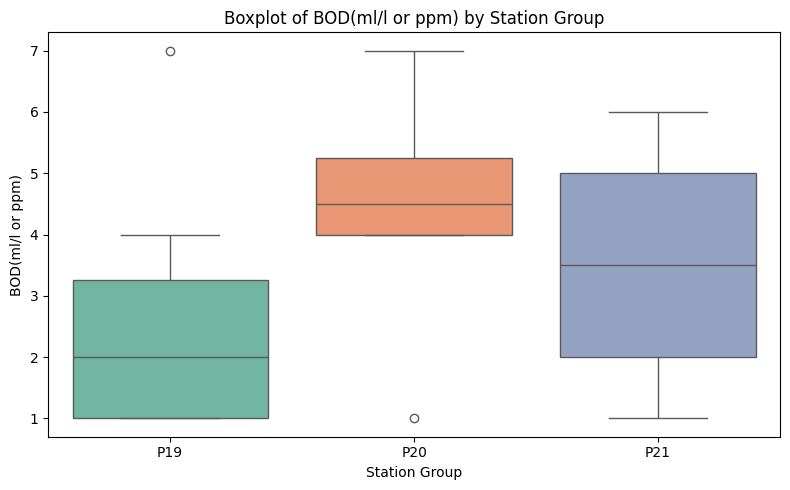

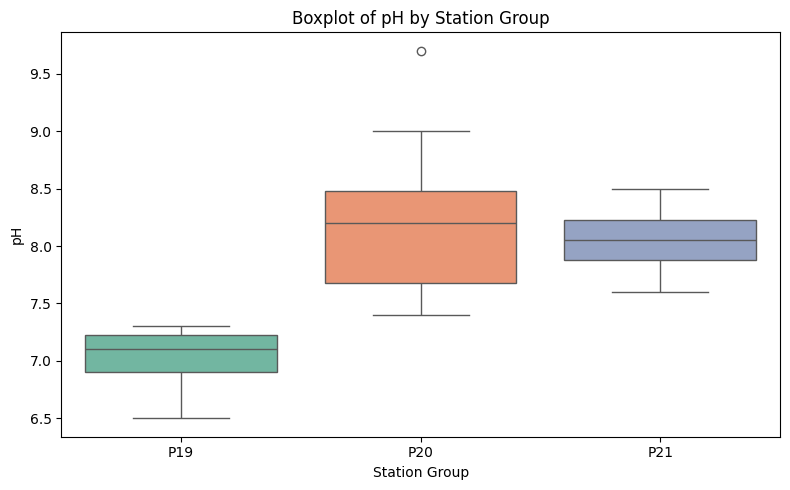

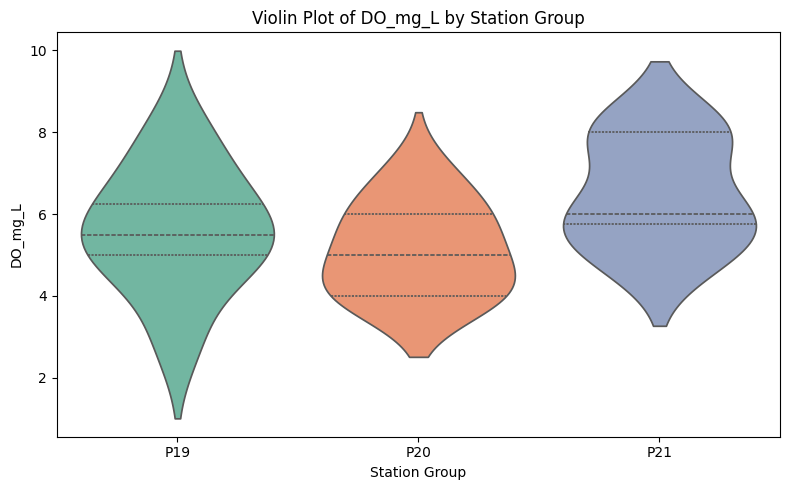

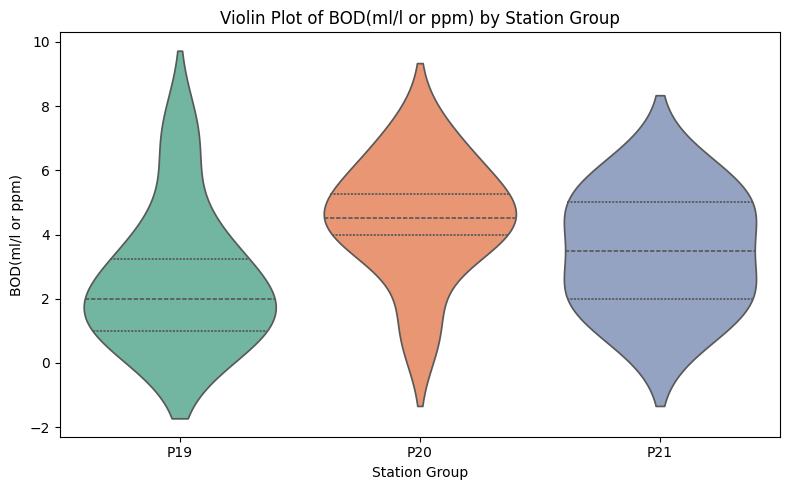

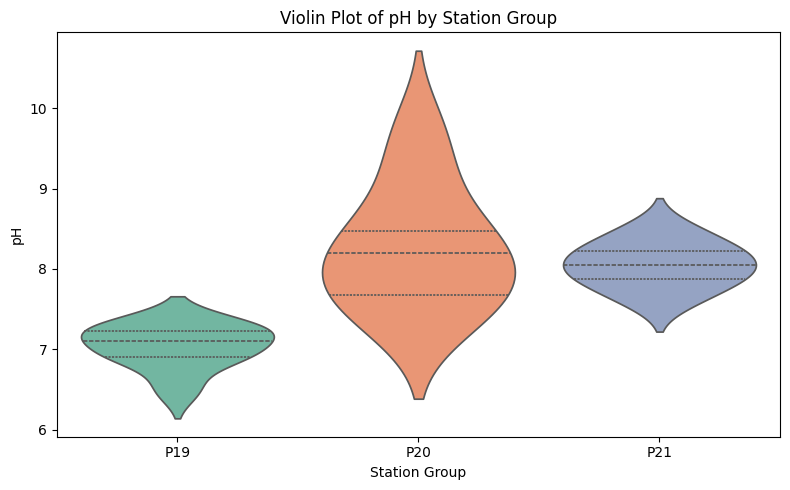

In [92]:
# 📦 Install & Import
!pip install pandas seaborn matplotlib openpyxl --quiet

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Extract Station Group (P19, P20, P21)
df['Station_Group'] = df['Sampling_Station'].str.extract(r'(P19|P20|P21)')

# 📊 Parameters to Plot
parameters = ['DO_mg_L', 'BOD(ml/l or ppm)', 'pH']

# 📈 Plot Boxplots
for param in parameters:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Station_Group', y=param, palette='Set2')
    plt.title(f'Boxplot of {param} by Station Group')
    plt.xlabel('Station Group')
    plt.ylabel(param)
    plt.tight_layout()
    plt.show()

# 🎻 Plot Violin Plots
for param in parameters:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df, x='Station_Group', y=param, palette='Set2', inner='quartile')
    plt.title(f'Violin Plot of {param} by Station Group')
    plt.xlabel('Station Group')
    plt.ylabel(param)
    plt.tight_layout()
    plt.show()


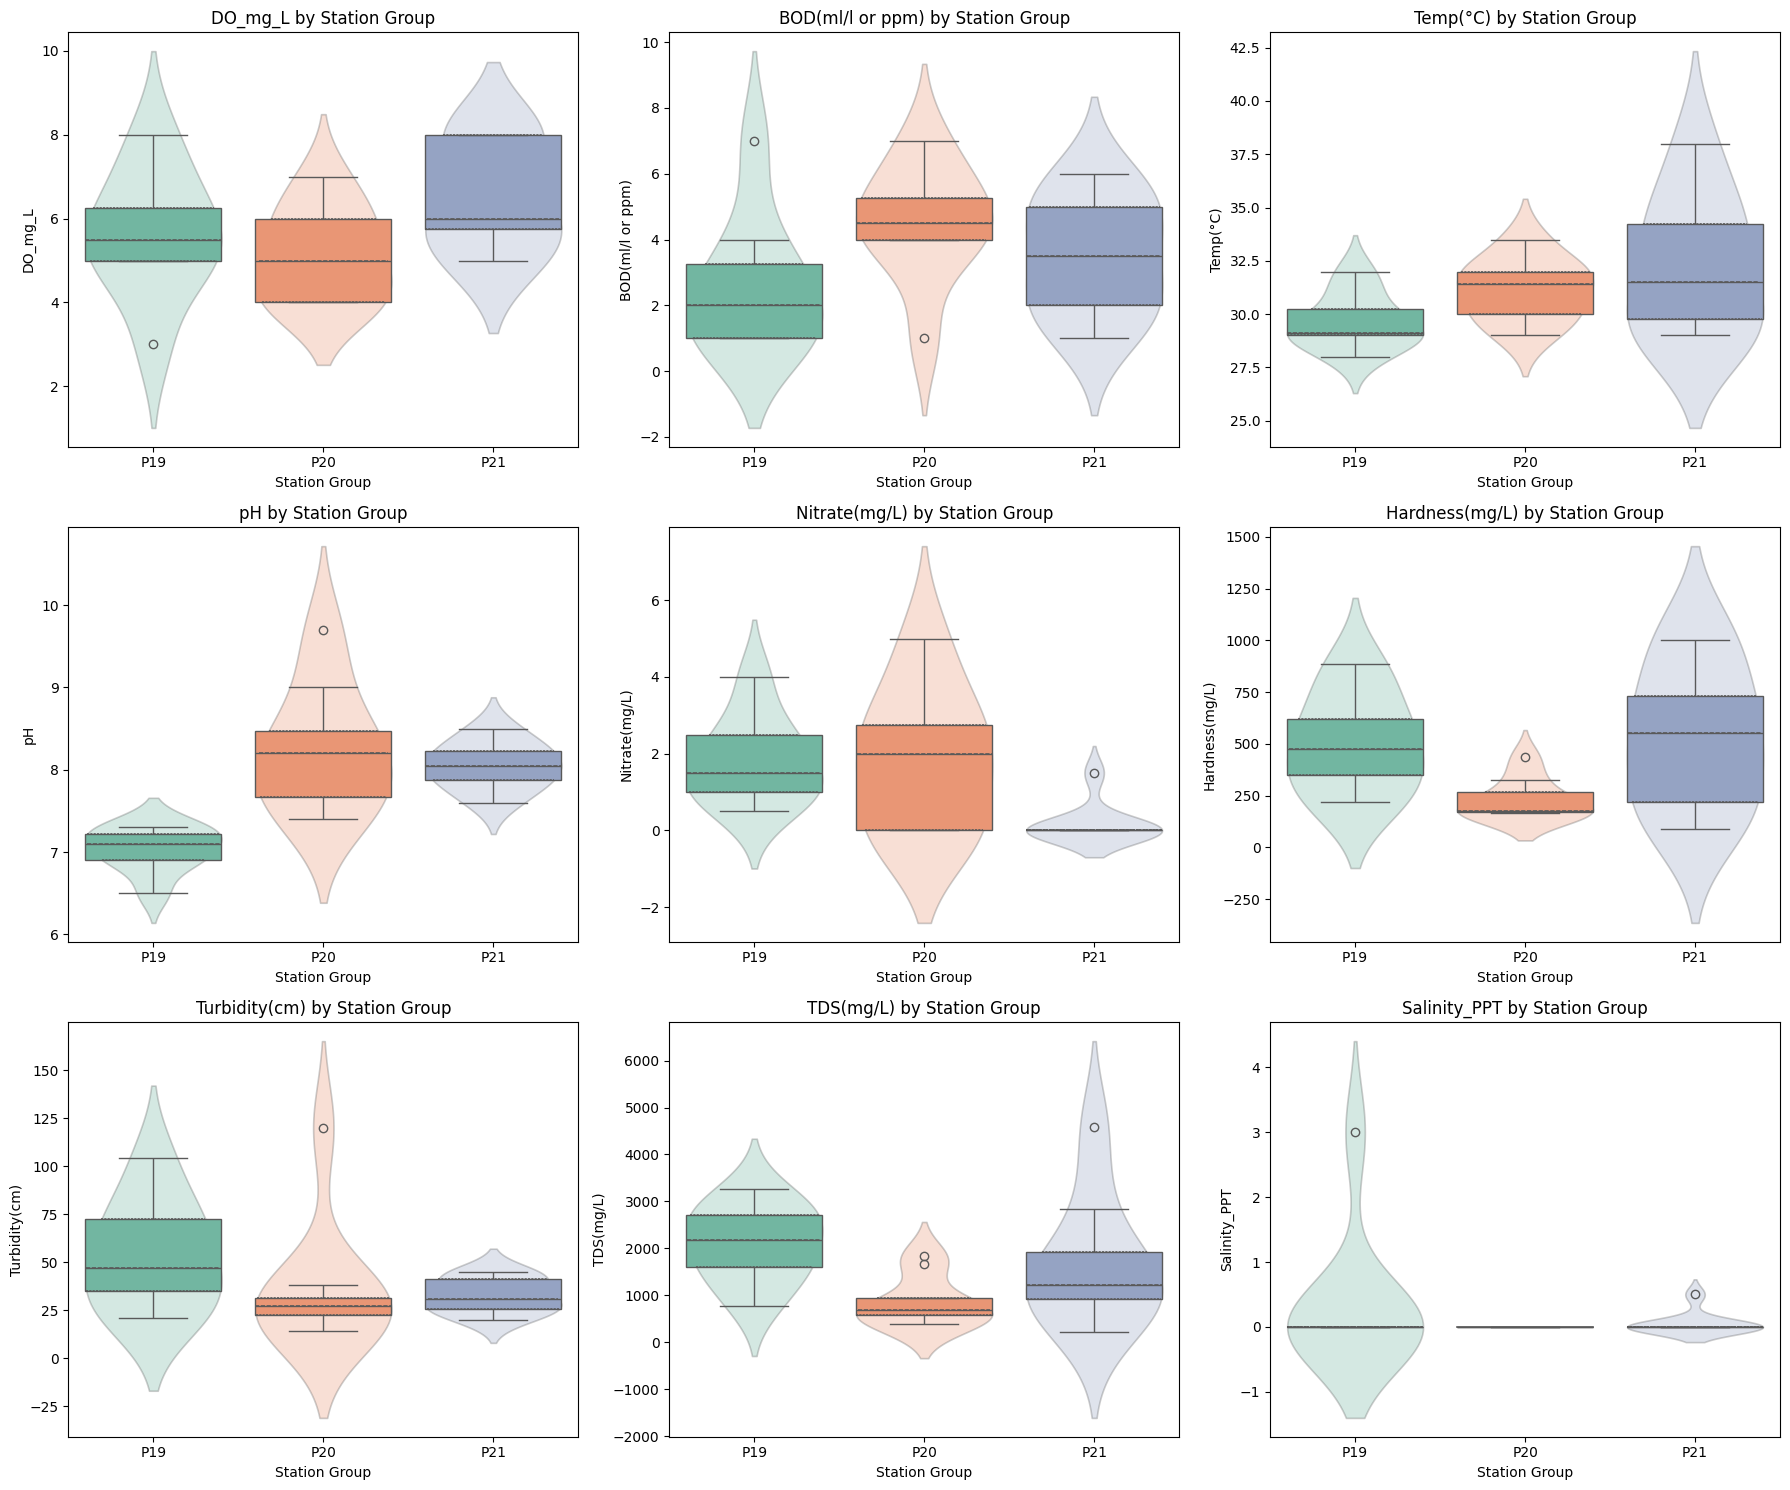

In [11]:
# Boxplots or Violin Plots by Station Group📦 Install & Import
!pip install pandas seaborn matplotlib openpyxl --quiet

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Extract Station Group (P19, P20, P21)
df['Station_Group'] = df['Sampling_Station'].str.extract(r'(P19|P20|P21)')

# 📊 Parameters to Plot
parameters = ['DO_mg_L', 'BOD(ml/l or ppm)', 'Temp(°C)', 'pH',
              'Nitrate(mg/L)', 'Hardness(mg/L)', 'Turbidity(cm)',
              'TDS(mg/L)', 'Salinity_PPT']

# 📈 Plot Side-by-Side Boxplots & Violin Plots
n_cols = 3
n_rows = int(len(parameters) / n_cols) + (len(parameters) % n_cols > 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, param in enumerate(parameters):
    sns.boxplot(data=df, x='Station_Group', y=param, ax=axes[i], palette='Set2')
    sns.violinplot(data=df, x='Station_Group', y=param, ax=axes[i], palette='Set2', inner='quartile', linewidth=1.2, alpha=0.3)
    axes[i].set_title(f'{param} by Station Group')
    axes[i].set_xlabel('Station Group')
    axes[i].set_ylabel(param)

# 🔧 Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


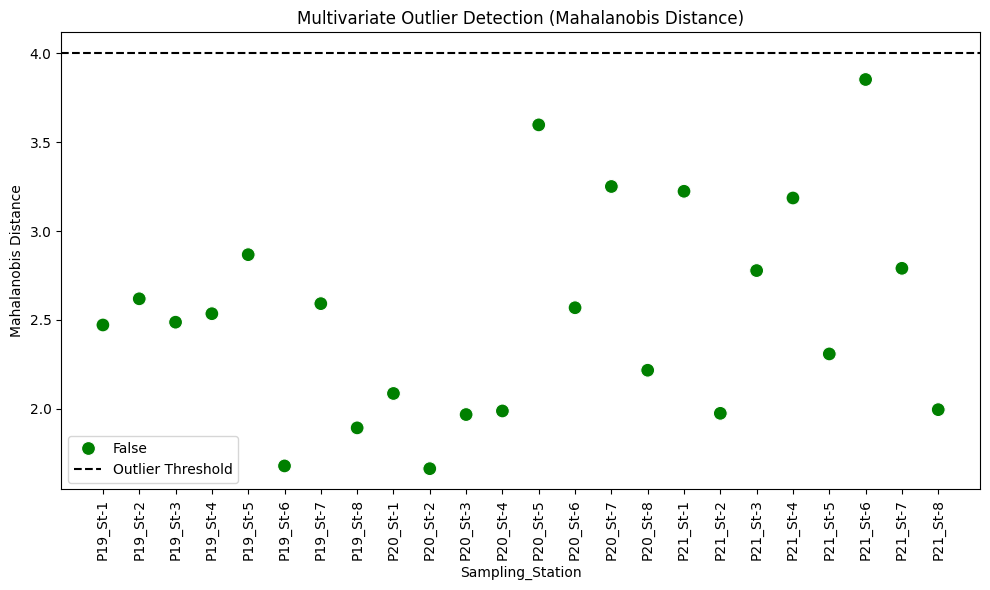

In [12]:
#Multivariate Outlier Detection
# 📦 Install & Import
!pip install pandas numpy scipy matplotlib seaborn openpyxl --quiet

import pandas as pd
import numpy as np
from scipy.stats import chi2
from scipy.spatial.distance import mahalanobis
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Select Relevant Numeric Features
features = ['DO_mg_L', 'BOD(ml/l or ppm)', 'Temp(°C)', 'pH',
            'Nitrate(mg/L)', 'Hardness(mg/L)', 'TDS(mg/L)']
df_clean = df[['Sampling_Station'] + features].dropna()

# 🔄 Standardize Features
X = df_clean[features].values
mean_vec = np.mean(X, axis=0)
cov_matrix = np.cov(X, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

# 🧪 Compute Mahalanobis Distance
distances = [mahalanobis(x, mean_vec, inv_cov_matrix) for x in X]
df_clean['Mahalanobis_Distance'] = distances

# 🎯 Set Threshold (Chi-square with df = number of features)
threshold = np.sqrt(chi2.ppf(0.975, df=len(features)))
df_clean['Outlier_Flag'] = df_clean['Mahalanobis_Distance'] > threshold

# 📊 Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Sampling_Station', y='Mahalanobis_Distance',
                hue='Outlier_Flag', palette={True: 'red', False: 'green'}, s=100)
plt.axhline(threshold, color='black', linestyle='--', label='Outlier Threshold')
plt.xticks(rotation=90)
plt.title('Multivariate Outlier Detection (Mahalanobis Distance)')
plt.ylabel('Mahalanobis Distance')
plt.legend()
plt.tight_layout()
plt.show()


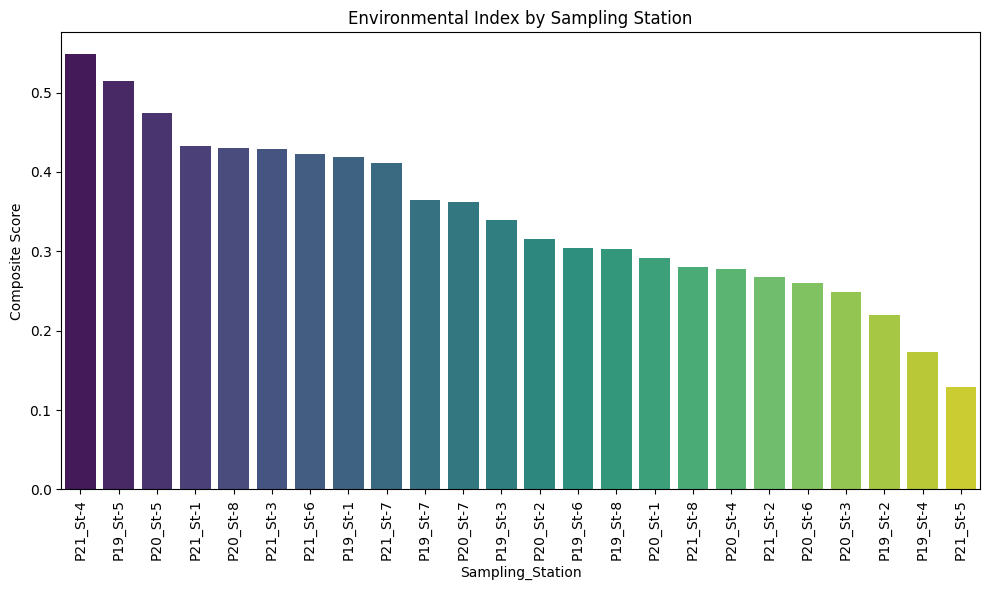

In [13]:
#Environmental Index Construction Workflow 📦 Install & Import
!pip install pandas numpy openpyxl matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Load Dataset
df = pd.read_excel('/content/overall_water_wuality.xlsx')

# 🧼 Select Parameters for Index
parameters = ['DO_mg_L', 'BOD(ml/l or ppm)', 'Temp(°C)', 'pH',
              'Nitrate(mg/L)', 'Hardness(mg/L)', 'TDS(mg/L)', 'Salinity_PPT']
df_clean = df[['Sampling_Station'] + parameters].dropna()

# 🔄 Normalize (Min-Max Scaling)
df_norm = df_clean.copy()
for col in parameters:
    min_val = df_clean[col].min()
    max_val = df_clean[col].max()
    df_norm[col] = (df_clean[col] - min_val) / (max_val - min_val)

# ⚖️ Assign Weights (customizable)
weights = {
    'DO_mg_L': 0.15,
    'BOD(ml/l or ppm)': 0.15,
    'Temp(°C)': 0.10,
    'pH': 0.10,
    'Nitrate(mg/L)': 0.15,
    'Hardness(mg/L)': 0.10,
    'TDS(mg/L)': 0.15,
    'Salinity_PPT': 0.10
}

# 🧮 Compute Environmental Index
df_norm['Environmental_Index'] = sum(df_norm[col] * weights[col] for col in parameters)

# 📊 Rank Stations
df_norm['Rank'] = df_norm['Environmental_Index'].rank(ascending=False)

# 📈 Visualize Top Stations
top_stations = df_norm.sort_values('Environmental_Index', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_stations, x='Sampling_Station', y='Environmental_Index', palette='viridis')
plt.xticks(rotation=90)
plt.title('Environmental Index by Sampling Station')
plt.ylabel('Composite Score')
plt.tight_layout()
plt.show()


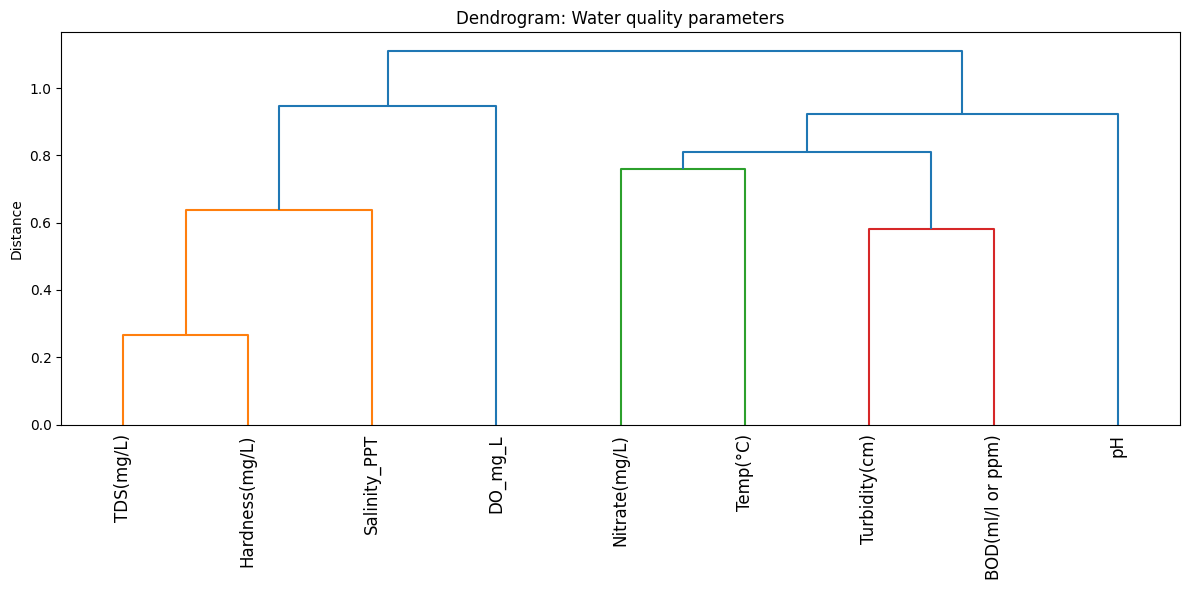

In [50]:
# Plot Dendrogram📦 Step 1: Install & Import Required Libraries
!pip install openpyxl seaborn matplotlib scipy pandas --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# 📂 Step 2: Load Dataset
file_path = '/content/overall_water_wuality.xlsx'  # Update path if needed
df = pd.read_excel(file_path)

# 🧼 Step 3: Select Numeric Parameters (Exclude Latitude & Longitude)
exclude_cols = ['Latitude', 'Longitude']
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=exclude_cols, errors='ignore').dropna()

# 📊 Step 4: Compute Pearson Correlation Matrix
corr_matrix = numeric_df.corr(method='pearson')

# 📐 Step 5: Convert Correlation to Distance Matrix
distance_matrix = 1 - np.abs(corr_matrix)
condensed_distance = squareform(distance_matrix.values)

# 🌿 Step 6: Perform Hierarchical Clustering (Ward Linkage)
linked = linkage(condensed_distance, method='ward')

# 📈 Step 7: Plot Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked,
           labels=corr_matrix.columns.tolist(),
           orientation='top',
           distance_sort='descending',
           leaf_rotation=90)
plt.title('Dendrogram: Water quality parameters', fontsize=12)
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


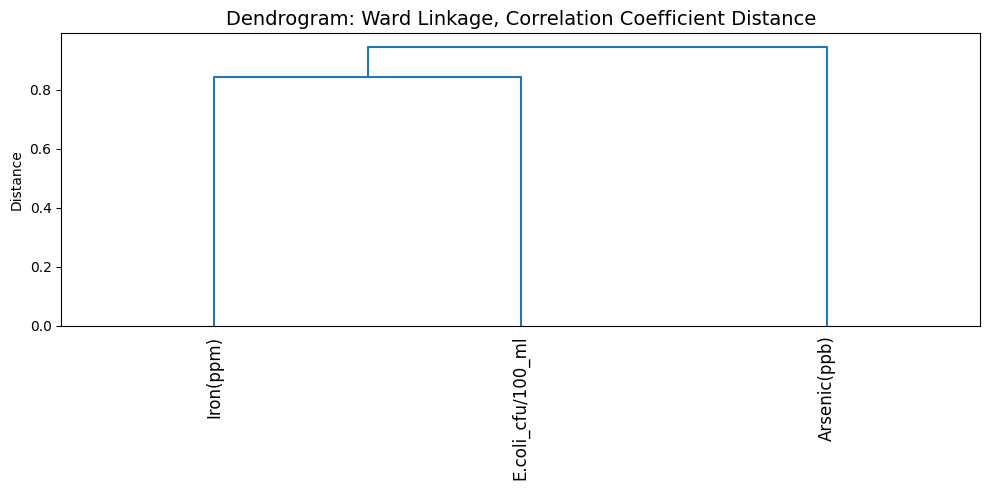

In [46]:
# 📦 Step 1: Install & Import Required Libraries
!pip install openpyxl seaborn matplotlib scipy pandas --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# 📂 Step 2: Load Dataset
file_path = '/content/drinking_water_quality.xlsx'  # Update if needed
df = pd.read_excel(file_path)

# 🧼 Step 3: Select Relevant Numeric Parameters (Exclude Latitude & Longitude)
exclude_cols = ['Latitude', 'Longitude']
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=exclude_cols, errors='ignore').dropna()

# 📊 Step 4: Compute Correlation Matrix
corr_matrix = numeric_df.corr(method='pearson')

# 📐 Step 5: Convert Correlation to Distance Matrix
distance_matrix = 1 - np.abs(corr_matrix)
condensed_distance = squareform(distance_matrix.values)

# 🌿 Step 6: Perform Hierarchical Clustering (Ward Linkage)
linked = linkage(condensed_distance, method='ward')

# 📈 Step 7: Plot Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked,
           labels=corr_matrix.columns.tolist(),
           orientation='top',
           distance_sort='descending',
           leaf_rotation=90)
plt.title('Dendrogram: Ward Linkage, Correlation Coefficient Distance', fontsize=14)
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


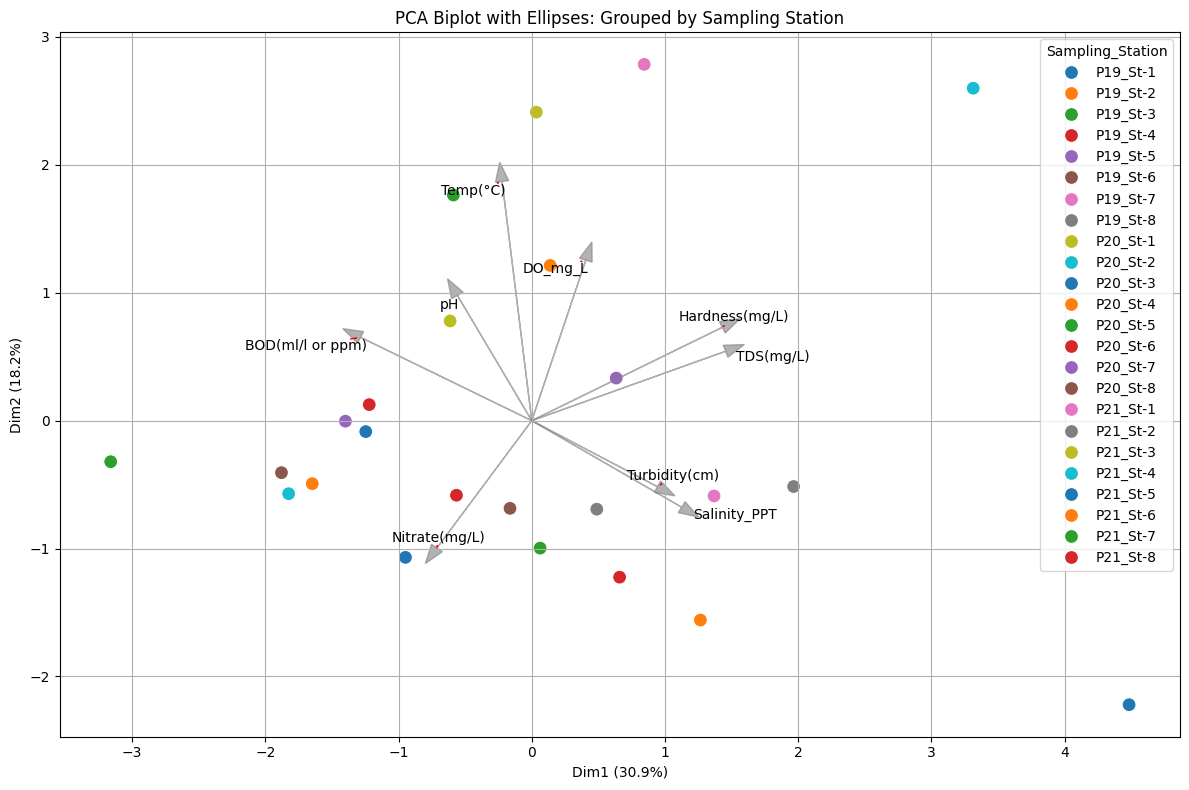

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from adjustText import adjust_text
from matplotlib.patches import Ellipse
import numpy as np

# Load dataset
df = pd.read_excel('overall_water_wuality.xlsx')

# Drop location columns
df = df.drop(columns=['Latitude', 'Longitude'], errors='ignore')

# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df_clean = df.dropna(subset=numeric_cols + ['Sampling_Station'])

# Standardize numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[numeric_cols])

# Run PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)
loadings = pca.components_.T

# Prepare DataFrame
pca_df = pd.DataFrame(scores, columns=['PC1', 'PC2'])
pca_df['Sampling_Station'] = df_clean['Sampling_Station'].values

# 🎨 Plot
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                     hue='Sampling_Station', palette='tab10', s=100)

# Add ellipses around each sampling station group
for group in pca_df['Sampling_Station'].unique():
    subset = pca_df[pca_df['Sampling_Station'] == group]
    if len(subset) > 1:
        cov = np.cov(subset[['PC1', 'PC2']].T)
        vals, vecs = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
        width, height = 2 * np.sqrt(vals)
        ellipse = Ellipse(xy=subset[['PC1', 'PC2']].mean(),
                          width=width, height=height,
                          angle=angle, alpha=0.2)
        ax.add_patch(ellipse)

# Arrows for loadings
texts = []
for i, var in enumerate(numeric_cols):
    x = loadings[i, 0] * 3
    y = loadings[i, 1] * 3
    plt.arrow(0, 0, x, y, color='gray', alpha=0.6, head_width=0.1)
    texts.append(plt.text(x, y, var, color='black', ha='center', va='center'))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Axis labels
explained = pca.explained_variance_ratio_ * 100
plt.xlabel(f'Dim1 ({explained[0]:.1f}%)')
plt.ylabel(f'Dim2 ({explained[1]:.1f}%)')
plt.title('PCA Biplot with Ellipses: Grouped by Sampling Station')
plt.grid(True)
plt.tight_layout()
plt.show()


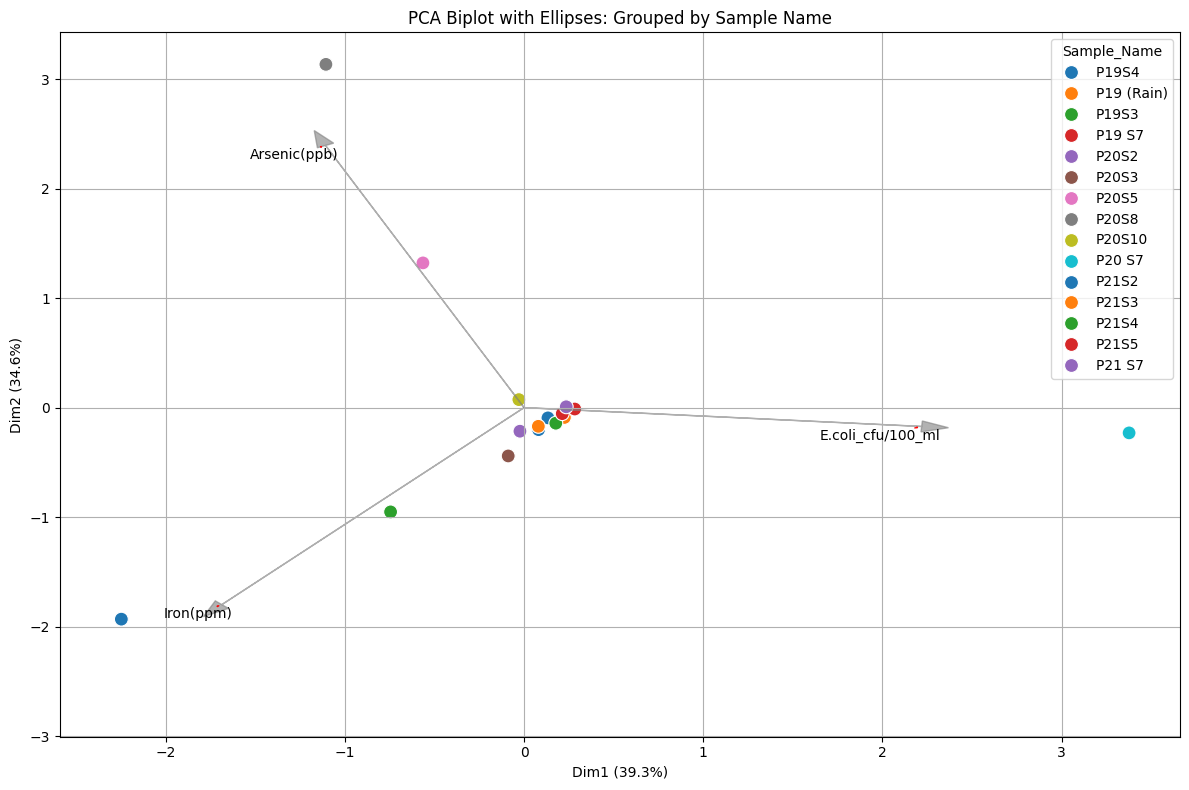

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from adjustText import adjust_text
from matplotlib.patches import Ellipse
import numpy as np

# Load dataset
df = pd.read_excel('drinking_water_quality.xlsx')

# Drop location columns
df = df.drop(columns=['Latitude', 'Longitude'], errors='ignore')

# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df_clean = df.dropna(subset=numeric_cols + ['Sample_Name'])

# Standardize numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[numeric_cols])

# Run PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)
loadings = pca.components_.T

# Prepare DataFrame
pca_df = pd.DataFrame(scores, columns=['PC1', 'PC2'])
pca_df['Sample_Name'] = df_clean['Sample_Name'].values

# 🎨 Plot
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                     hue='Sample_Name', palette='tab10', s=100)

# Add ellipses around each sample group
for group in pca_df['Sample_Name'].unique():
    subset = pca_df[pca_df['Sample_Name'] == group]
    if len(subset) > 1:
        cov = np.cov(subset[['PC1', 'PC2']].T)
        vals, vecs = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
        width, height = 2 * np.sqrt(vals)
        ellipse = Ellipse(xy=subset[['PC1', 'PC2']].mean(),
                          width=width, height=height,
                          angle=angle, alpha=0.2)
        ax.add_patch(ellipse)

# Arrows for loadings
texts = []
for i, var in enumerate(numeric_cols):
    x = loadings[i, 0] * 3
    y = loadings[i, 1] * 3
    plt.arrow(0, 0, x, y, color='gray', alpha=0.6, head_width=0.1)
    texts.append(plt.text(x, y, var, color='black', ha='center', va='center'))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# Axis labels
explained = pca.explained_variance_ratio_ * 100
plt.xlabel(f'Dim1 ({explained[0]:.1f}%)')
plt.ylabel(f'Dim2 ({explained[1]:.1f}%)')
plt.title('PCA Biplot with Ellipses: Grouped by Sample Name')
plt.grid(True)
plt.tight_layout()
plt.show()


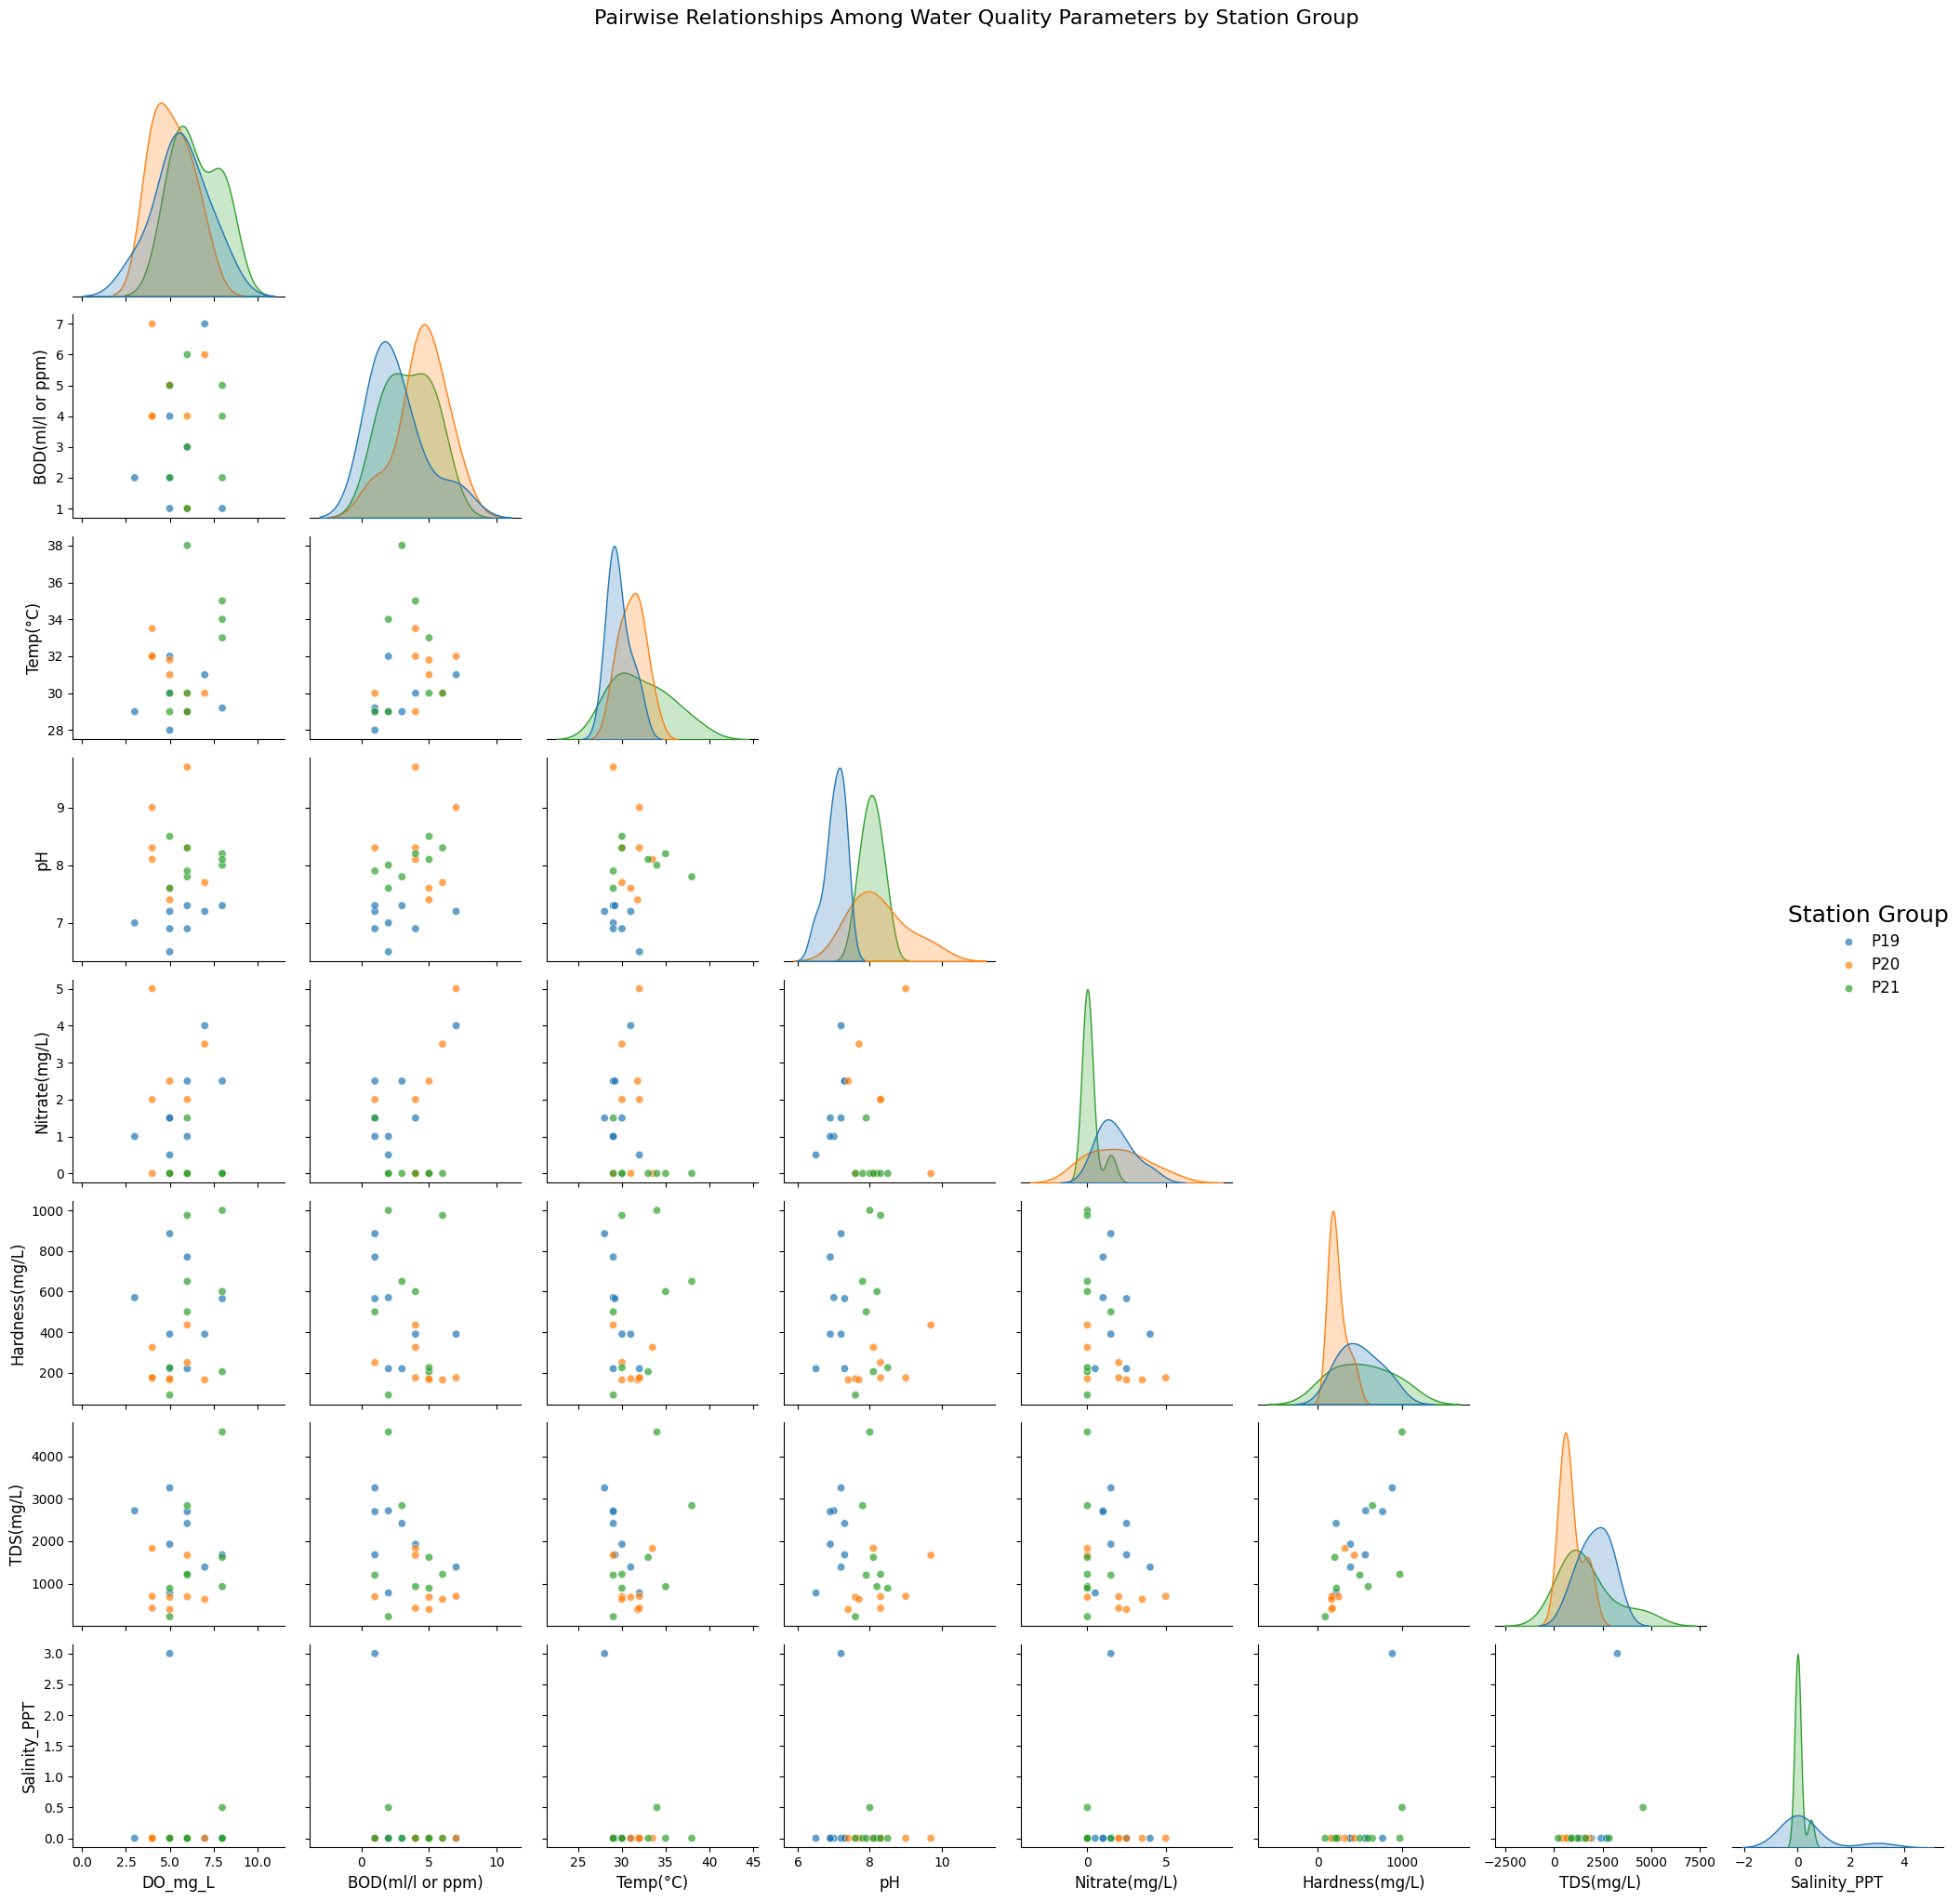

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 🧪 Pairplot with font size control
g = sns.pairplot(df_clean, hue='Station_Group', diag_kind='kde', corner=True, plot_kws={'alpha': 0.7})

# 🎨 Customize font sizes
g.fig.suptitle('Pairwise Relationships Among Water Quality Parameters by Station Group', y=1.02, fontsize=16)  # Title
for ax in g.axes.flatten():
    if ax:  # Check if subplot exists
        ax.set_xlabel(ax.get_xlabel(), fontsize=12)
        ax.set_ylabel(ax.get_ylabel(), fontsize=12)
        ax.tick_params(axis='both', labelsize=10)

# 🖼️ Legend font size
g._legend.set_title('Station Group')
for text in g._legend.texts:
    text.set_fontsize(12)
g._legend.set_title('Station Group', prop={'size': 18})

plt.tight_layout()
plt.show()


# Drinking water quality

In [22]:
# Install required packages (run this first in Google Colab)
!pip install numpy pandas matplotlib seaborn

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
!pip install adjustText

In [37]:
from google.colab import files
uploaded = files.upload()


# Load data
df = pd.read_excel("drinking_water_quality.xlsx")
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')
from adjustText import adjust_text  # Now this will work!

Saving drinking_water_quality.xlsx to drinking_water_quality (2).xlsx


In [38]:
import pandas as pd

# Load dataset
df = pd.read_excel('/content/drinking_water_quality.xlsx')

# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# Preview
df.head()


,Sample_Name,Water_sources,E.coli_cfu/100_ml,Arsenicppb,Ironppm,Latitude,Longitude
0,P19S4,Tubewell,0.0,19.2278,0.480602,22.621444,89.356942
1,P19S4,Homestead Pond,0.0,4.4830,0.054430,22.626193,89.356882
2,P19 (Rain),Rainwater Harvest,0.0,3.6538,0.027794,22.658333,89.356667
3,P19S3,Tubewell,0.0,7.0225,0.214244,22.647264,89.362084
4,P19 S7,Commercial Gher,0.0,3.9521,0.015055,22.605647,89.370753


In [40]:
# Grouped summary
summary = df.groupby('Water_sources')[['E.coli_cfu/100_ml', 'Arsenicppb', 'Ironppm']].describe()
print(summary)


                    E.coli_cfu/100_ml                                       \
                                count       mean        std  min  25%  50%   
Water_sources                                                                
Commercial Gher                   3.0  13.666667  23.671361  0.0  0.0  0.0   
Drinking water pond               1.0   0.000000        NaN  0.0  0.0  0.0   
Homestead Pond                    5.0   0.000000   0.000000  0.0  0.0  0.0   
Rainwater Harvest                 1.0   0.000000        NaN  0.0  0.0  0.0   
River water                       1.0   0.000000        NaN  0.0  0.0  0.0   
Tubewell                          5.0   0.000000   0.000000  0.0  0.0  0.0   

                                Arsenicppb             ...                    \
                      75%   max      count       mean  ...      75%      max   
Water_sources                                          ...                     
Commercial Gher      20.5  41.0        3.0   3.702867  ..

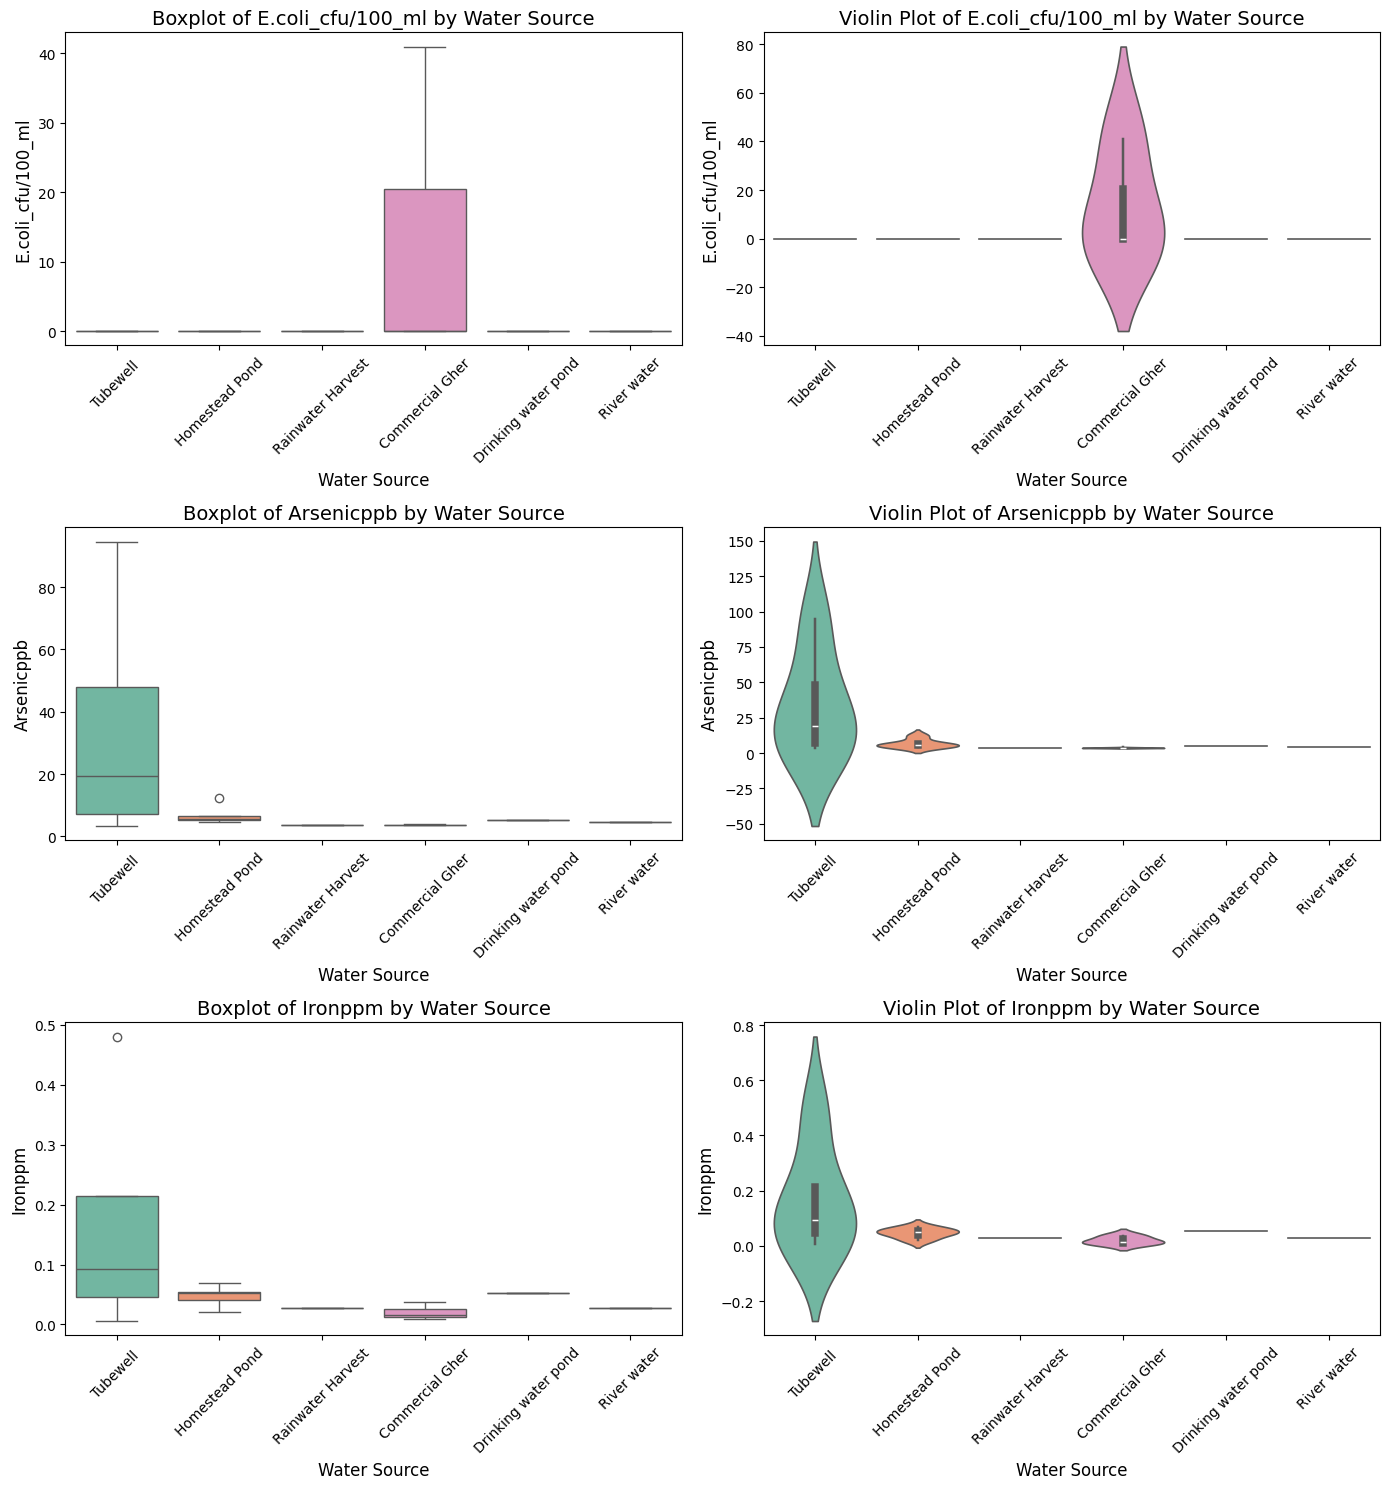

In [45]:
# 📦 Install & Import
!pip install pandas seaborn matplotlib openpyxl --quiet

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Load Dataset
df = pd.read_excel('/content/drinking_water_quality.xlsx')

# 🧼 Clean Column Names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# 📊 Parameters to Plot
parameters = ['E.coli_cfu/100_ml', 'Arsenicppb', 'Ironppm']
n_rows = len(parameters)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))

for i, param in enumerate(parameters):
    # 📦 Boxplot
    sns.boxplot(data=df, x='Water_sources', y=param, ax=axes[i, 0], palette='Set2')
    axes[i, 0].set_title(f'Boxplot of {param} by Water Source', fontsize=14)
    axes[i, 0].set_xlabel('Water Source', fontsize=12)
    axes[i, 0].set_ylabel(param, fontsize=12)
    axes[i, 0].tick_params(axis='x', labelrotation=45)

    # 🎻 Violin Plot
    sns.violinplot(data=df, x='Water_sources', y=param, ax=axes[i, 1], palette='Set2', inner='box', linewidth=1.2)
    axes[i, 1].set_title(f'Violin Plot of {param} by Water Source', fontsize=14)
    axes[i, 1].set_xlabel('Water Source', fontsize=12)
    axes[i, 1].set_ylabel(param, fontsize=12)
    axes[i, 1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()


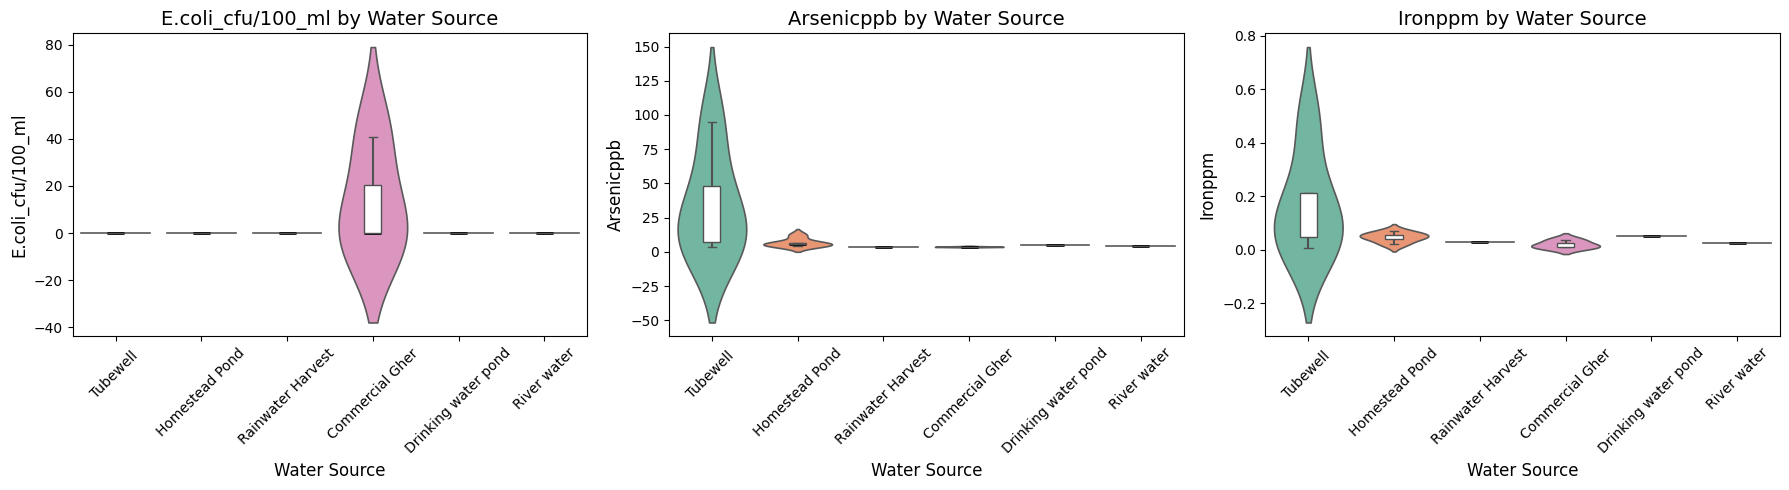

In [47]:
# 📦 Install & Import
!pip install pandas seaborn matplotlib openpyxl --quiet

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Load Dataset
df = pd.read_excel('/content/drinking_water_quality.xlsx')

# 🧼 Clean Column Names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# 📊 Parameters to Plot
parameters = ['E.coli_cfu/100_ml', 'Arsenicppb', 'Ironppm']
n_rows = 1
n_cols = len(parameters)

# 🎨 Create Subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5), sharey=False)
axes = axes.flatten()

for i, param in enumerate(parameters):
    sns.violinplot(data=df, x='Water_sources', y=param, ax=axes[i],
                   palette='Set2', inner=None, linewidth=1.2)
    sns.boxplot(data=df, x='Water_sources', y=param, ax=axes[i],
                width=0.2, boxprops={'facecolor':'white', 'zorder':10},
                showcaps=True, showfliers=False, whiskerprops={'linewidth':1.5},
                medianprops={'color':'black', 'linewidth':2})

    axes[i].set_title(f'{param} by Water Source', fontsize=14)
    axes[i].set_xlabel('Water Source', fontsize=12)
    axes[i].set_ylabel(param, fontsize=12)
    axes[i].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()


In [49]:
# Pearson
print("📌 Pearson Correlation")
print(df[['E.coli_cfu/100_ml', 'Arsenicppb', 'Ironppm']].corr(method='pearson'))

# Spearman
print("📌 Spearman Correlation")
print(df[['E.coli_cfu/100_ml', 'Arsenicppb', 'Ironppm']].corr(method='spearman'))


📌 Pearson Correlation
                   E.coli_cfu/100_ml  Arsenicppb   Ironppm
E.coli_cfu/100_ml           1.000000   -0.120152 -0.156144
Arsenicppb                 -0.120152    1.000000 -0.040681
Ironppm                    -0.156144   -0.040681  1.000000
📌 Spearman Correlation
                   E.coli_cfu/100_ml  Arsenicppb   Ironppm
E.coli_cfu/100_ml           1.000000   -0.364073 -0.364073
Arsenicppb                 -0.364073    1.000000  0.179412
Ironppm                    -0.364073    0.179412  1.000000


📌 Pearson Correlation Matrix
                   E.coli_cfu/100_ml  Arsenicppb   Ironppm
E.coli_cfu/100_ml           1.000000   -0.120152 -0.156144
Arsenicppb                 -0.120152    1.000000 -0.040681
Ironppm                    -0.156144   -0.040681  1.000000

📌 Spearman Correlation Matrix
                   E.coli_cfu/100_ml  Arsenicppb   Ironppm
E.coli_cfu/100_ml           1.000000   -0.364073 -0.364073
Arsenicppb                 -0.364073    1.000000  0.179412
Ironppm                    -0.364073    0.179412  1.000000


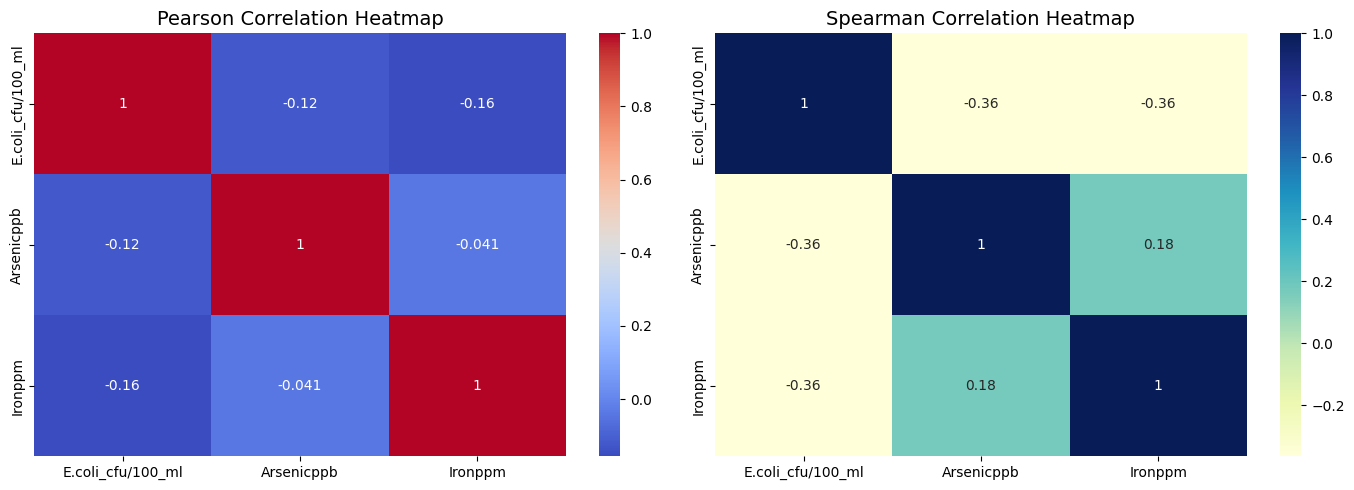

In [51]:
# 📦 Install & Import
!pip install pandas seaborn matplotlib openpyxl --quiet

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Load Dataset
df = pd.read_excel('/content/drinking_water_quality.xlsx')

# 🧼 Clean Column Names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# 🎯 Select Numeric Parameters
params = ['E.coli_cfu/100_ml', 'Arsenicppb', 'Ironppm']
df_corr = df[params].dropna()

# 📊 Pearson Correlation Matrix
pearson_corr = df_corr.corr(method='pearson')
print("📌 Pearson Correlation Matrix")
print(pearson_corr)

# 📊 Spearman Correlation Matrix
spearman_corr = df_corr.corr(method='spearman')
print("\n📌 Spearman Correlation Matrix")
print(spearman_corr)

# 🔥 Heatmap Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Pearson Correlation Heatmap', fontsize=14)

sns.heatmap(spearman_corr, annot=True, cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Spearman Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()


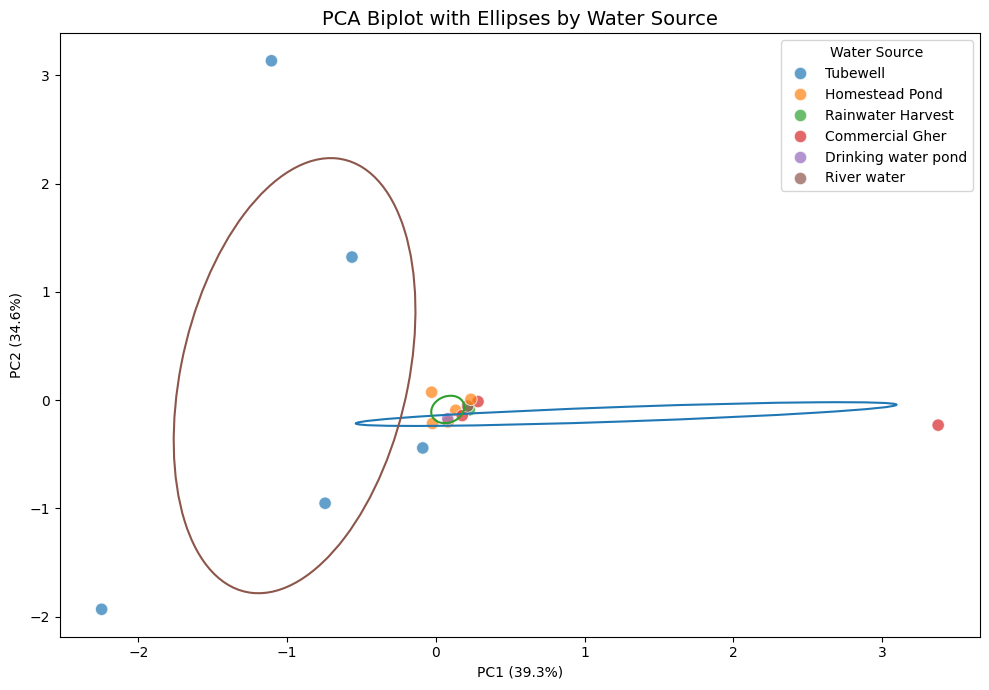

In [62]:
# 📦 Install & Import
!pip install pandas matplotlib seaborn scikit-learn openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse

# 📂 Load Dataset
df = pd.read_excel('/content/drinking_water_quality.xlsx')

# 🧼 Clean Column Names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

# 🎯 Select Features & Group
features = ['E.coli_cfu/100_ml', 'Arsenicppb', 'Ironppm']
group_col = 'Water_sources'
df_clean = df[features + [group_col]].dropna()

# 🔄 Standardize Features
X = StandardScaler().fit_transform(df_clean[features])
groups = df_clean[group_col]

# 🧪 PCA
pca = PCA(n_components=2)
components = pca.fit_transform(X)
df_pca = pd.DataFrame(components, columns=['PC1', 'PC2'])
df_pca[group_col] = groups.values

# ➰ Robust Ellipse Drawing Function
def draw_ellipse(x, y, ax, edgecolor='black'):
    if len(x) < 3 or np.isnan(x).any() or np.isnan(y).any():
        return
    cov = np.cov(x, y)
    if np.any(np.isnan(cov)) or np.any(np.isinf(cov)):
        return
    lambda_, v = np.linalg.eig(cov)
    lambda_ = np.sqrt(lambda_)
    ell = Ellipse(xy=(np.mean(x), np.mean(y)),
                  width=lambda_[0]*2, height=lambda_[1]*2,
                  angle=np.rad2deg(np.arccos(v[0, 0])),
                  edgecolor=edgecolor, facecolor='none', linewidth=1.5)
    ax.add_patch(ell)

# 📊 Plot PCA Biplot with Ellipses
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=group_col, s=80, alpha=0.7)

ax = plt.gca()
for name, group in df_pca.groupby(group_col):
    draw_ellipse(group['PC1'], group['PC2'], ax, edgecolor=ax._get_lines.get_next_color())

plt.title('PCA Biplot with Ellipses by Water Source', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Water Source')
plt.tight_layout()
plt.show()
